# Music Genre Classification using ViT and Mel Spectograms

## 0. Importing libraries, setting up device agnostic code

In [12]:
import json
import numpy as np
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torchaudio
import matplotlib.pyplot as plt

print(torch.__version__)
print(torchaudio.__version__)

2.7.0+cu118
2.7.0+cu118


In [13]:
# Set seeds
def set_seeds(seed: int=42):
    """Sets random sets for torch operations.

    Args:
        seed (int, optional): Random seed to set. Defaults to 42.
    """
    # Set the seed for general torch operations
    torch.manual_seed(seed)
    # Set the seed for CUDA torch operations (ones that happen on the GPU)
    torch.cuda.manual_seed(seed)

In [14]:
# Set random seeds
RANDOM_SEED = 42

set_seeds()
np.random.seed(RANDOM_SEED)

In [15]:
!nvidia-smi

Fri Feb  6 18:18:56 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 591.74                 Driver Version: 591.74         CUDA Version: 13.1     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 4060      WDDM  |   00000000:01:00.0  On |                  N/A |
|  0%   42C    P8            N/A  /  115W |    1109MiB /   8188MiB |      1%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [16]:
# Create device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

## 1. Loading data
We will load the data and after loading them in shape of `(batch_size, time_frames, mel_bands)`. Then we will reshape into a 72x72 matrix, all according to the following paper - https://ieeexplore.ieee.org/document/9573568
We could optionally permute the tensor to have the shape of `(batch_size, time_frames, mel_bands)`, however this is not the shape mentioned in the paper. We could test it though.

In [17]:
# Create function to load melspec data from .json file
def load_data(dataset_path):
    with open(dataset_path, 'r') as fp:
        data = json.load(fp)

    # Convert
    X = np.array(data['melspec'])
    y = np.array(data['labels'])

    return X, y

In [18]:
# Create function to load classes from .json file
def load_classes(dataset_path):
    with open(dataset_path, 'r') as fp:
        data = json.load(fp)
    classes = data['mapping']
    return classes

In [19]:
# Load classes
DATASET_PATH = "data_full.json"

classes = load_classes(DATASET_PATH)
print(classes)

['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']


In [20]:
# Load data
inputs, labels = load_data(DATASET_PATH)
inputs.shape, labels.shape

((3000, 997, 128), (3000,))

In [21]:
# Turn data into tensors, also unsqueeze and permute, to be ready for Transformer
X = torch.from_numpy(inputs).float() # Weight calculations expect float
y = torch.from_numpy(labels).long() # CrossEntropyLoss expects long
# X = X.permute(0, 2, 1).unsqueeze(1)
X = X.unsqueeze(1)
X.shape, y.shape

(torch.Size([3000, 1, 997, 128]), torch.Size([3000]))

In [22]:
# Resize Spectrogram
import torch.nn.functional as F
X = F.interpolate(X, size=(72, 72), mode="bilinear", align_corners=False)
X.shape

torch.Size([3000, 1, 72, 72])

## 2. Create DataSets and DataLoaders

In [23]:
# Creating a function to divide the sets
def divide_sets(X, y, test_size, validation_size, random_state=None):
    # create train/validation split

    # create train/test split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=random_state)

    X_train, X_validation, y_train, y_validation = train_test_split(X_train, y_train, test_size=validation_size, random_state=random_state)

    return X_train, X_validation, X_test, y_train, y_validation, y_test

In [24]:
# Create train, validation and test sets test size is 25% of the whole set. Validation size is 20% of the remaining train_set
X_train, X_validation, X_test, y_train, y_validation, y_test = divide_sets(X, y, test_size=0.25,
                                                                                validation_size=0.2,
                                                                                random_state=RANDOM_SEED)

In [25]:
# Check if data is divided correctly
print(X.shape[0] == X_train.shape[0] + X_validation.shape[0] + X_test.shape[0])
print(y.shape[0] == y_train.shape[0] + y_validation.shape[0] + y_test.shape[0])

True
True


In [26]:
# Create datasets and dataloaders
from torch.utils.data import TensorDataset, DataLoader

BATCH_SIZE=32
torch.manual_seed(RANDOM_SEED)

train_dataset = TensorDataset(X_train, y_train)
validation_dataset = TensorDataset(X_validation, y_validation)
test_dataset = TensorDataset(X_test, y_test)

train_dataloader = DataLoader(train_dataset,
                          batch_size=BATCH_SIZE,
                          shuffle=True)
validation_dataloader = DataLoader(validation_dataset,
                                   batch_size=BATCH_SIZE,)
test_dataloader = DataLoader(test_dataset,
                         batch_size=BATCH_SIZE)

print(f"Dataloaders: {train_dataloader, test_dataloader}")
print(f"Length of train dataloader: {len(train_dataloader)} batches of {BATCH_SIZE}")
print(f"Length of validation dataloader: {len(validation_dataloader)} batches of {BATCH_SIZE}")
print(f"Length of test dataloader: {len(test_dataloader)} batches of {BATCH_SIZE}")

Dataloaders: (<torch.utils.data.dataloader.DataLoader object at 0x00000221DB66C440>, <torch.utils.data.dataloader.DataLoader object at 0x00000221DB55B9D0>)
Length of train dataloader: 57 batches of 32
Length of validation dataloader: 15 batches of 32
Length of test dataloader: 24 batches of 32


In [27]:
# Checking the dataset shapes using test_dataset
test_features_batch, test_labels_batch = next(iter(test_dataloader))
print(test_features_batch.shape, "-> (batch_size, time_frames, mel_bands)")
print(test_labels_batch.shape, "-> (batch_size,) each entry is the class index of a sample")
print(test_features_batch[0].shape, "-> (time_frames, mel_bands)")
print(test_labels_batch[0], "-> (label)")

torch.Size([32, 1, 72, 72]) -> (batch_size, time_frames, mel_bands)
torch.Size([32]) -> (batch_size,) each entry is the class index of a sample
torch.Size([1, 72, 72]) -> (time_frames, mel_bands)
tensor(6) -> (label)


## 3. Data visualization

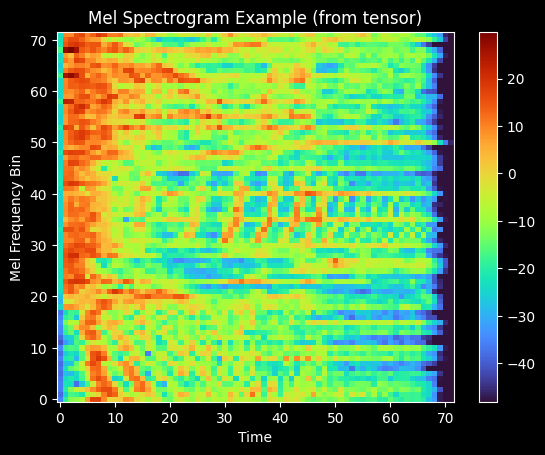

In [28]:
# Visualise data
np.random.seed(RANDOM_SEED)
INDEX = np.random.randint(len(X))
melspec_example = X[INDEX].squeeze(0).numpy()

plt.imshow(melspec_example, cmap='turbo', aspect='auto', origin='lower')
plt.colorbar()
plt.title("Mel Spectrogram Example (from tensor)")
plt.xlabel("Time")
plt.ylabel("Mel Frequency Bin")
plt.show()

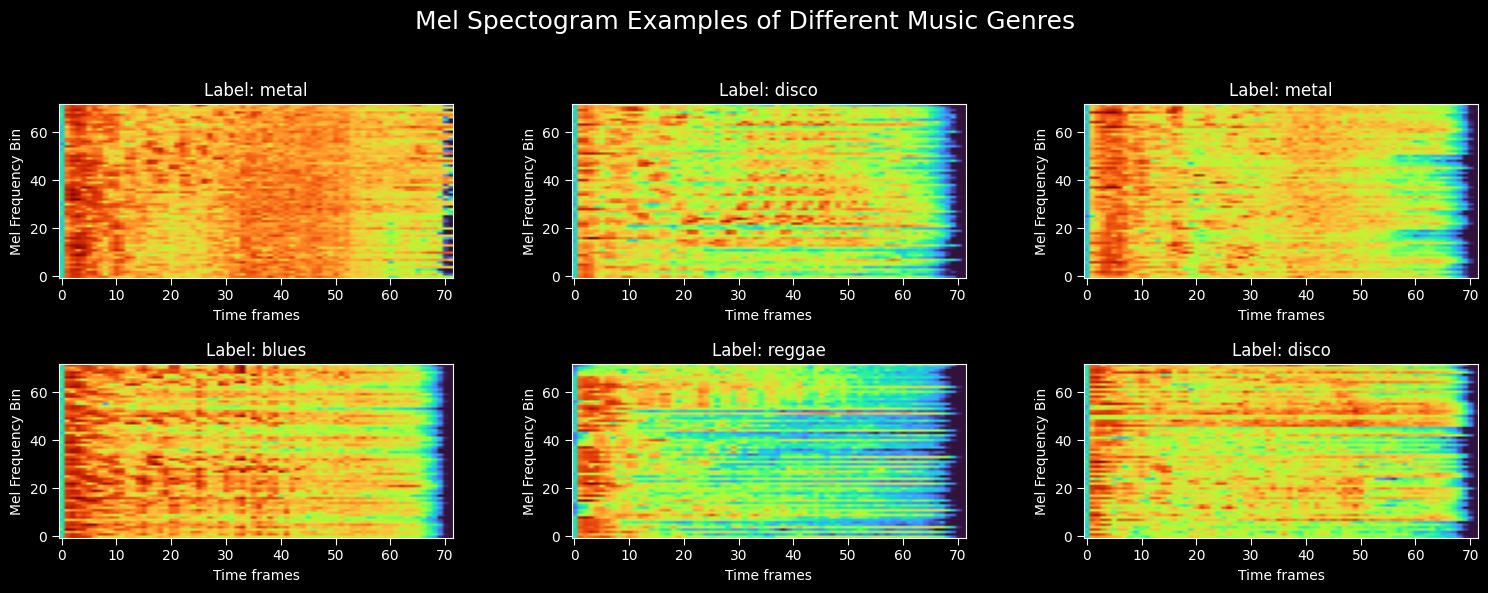

In [29]:
# Vizualize different genres
np.random.seed(RANDOM_SEED)
indices = np.random.choice(len(X), size=6, replace=False)

fig, axs = plt.subplots(2, 3, figsize=(15, 6),constrained_layout=False)
fig.suptitle("Mel Spectogram Examples of Different Music Genres", fontsize=18)

for i, idx in enumerate(indices):
    row = i // 3
    col = i % 3
    melspec_example = X[idx].squeeze(0).numpy()
    im = axs[row, col].imshow(melspec_example, cmap='turbo', aspect='auto', origin='lower')
    axs[row, col].set_title(f"Label: {classes[y[idx]]}")
    axs[row, col].set_xlabel("Time frames")
    axs[row, col].set_ylabel("Mel Frequency Bin")
    axs[row, col].tick_params(axis='both', which='both', length=5)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.subplots_adjust(wspace=0.3, hspace=0.5)
plt.show()

## 4. Building a ViT Model

### Create patch embeddings

In [30]:
# 1. Create a class called PatchEmbedding
class PatchEmbedding(nn.Module):
  # 2. Initilaize the layer with appropriate hyperparameters
  def __init__(self,
               in_channels:int=1,
               patch_size:int=12,
               embedding_dim:int=768): # from Table 1 for ViT-Base
    super().__init__()

    self.patch_size = patch_size

    # 3. Create a layer to turn an image into embedded patches
    self.patcher = nn.Conv2d(in_channels=in_channels,
                             out_channels=embedding_dim,
                             kernel_size=patch_size,
                             stride=patch_size,
                             padding=0)

    # 4. Create a layer to flatten feature map outputs of Conv2d
    self.flatten = nn.Flatten(start_dim=2,
                              end_dim=3)

  # 5. Define a forward method to define the forward computation steps
  def forward(self, x):
    # Create assertion to check that inputs are the correct shape
    graph_resolution = x.shape[-1]
    assert graph_resolution % self.patch_size == 0, f"Input image size must be divisible by patch size, image shape: {graph_resolution}, patch size: {self.patch_size}"

    # Perform the forward pass
    x_patched = self.patcher(x)
    x_flattened = self.flatten(x_patched)
    # 6. Make the returned sequence embedding dimensions are in the right order (batch_size, number_of_patches, embedding_dimension)
    return x_flattened.permute(0, 2, 1)


In [31]:
# Patchify a random sample

# Select a sample
np.random.seed(RANDOM_SEED)
INDEX = np.random.randint(len(X))
melspec_sample = X[INDEX]

# Create an instance of patch embedding layer
patchify = PatchEmbedding(in_channels=1,
                          patch_size=12,
                          embedding_dim=768)

# Pass the sample through patch embedding layer
print(f"Input image size: {melspec_sample.unsqueeze(0).shape}")
patch_embedded_image = patchify(melspec_sample.unsqueeze(0)) # add an extra batch dimension
print(f"Output patch embedding sequence shape: {patch_embedded_image.shape}")

Input image size: torch.Size([1, 1, 72, 72])
Output patch embedding sequence shape: torch.Size([1, 36, 768])


In [32]:
class ViT(nn.Module):
  def __init__(self,
               graph_size=72,
               num_channels=1,
               patch_size=12,
               embedding_dim=768,  # from Table 1
               dropout=0.1,
               mlp_size=3072,  # from Table 1
               num_transformer_layers=12,  # from Table 1
               num_heads=12,  # from Table 1 (number of multi-head self attention heads)
               num_classes=10): # number of GTZAN classes
    super().__init__()

    # Assert image size is divisible by patch size
    assert graph_size % patch_size == 0, "Graph size must be divisble by patch size."

    # 1. Create patch embedding
    self.patch_embedding = PatchEmbedding(in_channels=num_channels,
                                          patch_size=patch_size,
                                          embedding_dim=embedding_dim)

    # 2. Create class token
    self.class_token = nn.Parameter(torch.randn(1, 1, embedding_dim),
                                    requires_grad=True)

    # 3. Create positional embedding
    num_patches = (graph_size * graph_size) // patch_size ** 2 # N = HW/P^2
    self.positional_embedding = nn.Parameter(torch.randn(1, num_patches+1, embedding_dim))

    # 4. Create patch + position embedding dropout
    self.embedding_dropout = nn.Dropout(p=dropout)

    # # 5. Create Transformer Encoder layer (single)
    # self.transformer_encoder_layer = nn.TransformerEncoderLayer(d_model=embedding_dim,
    #                                                             nhead=num_heads,
    #                                                             dim_feedforward=mlp_size,
    #                                                             activation="gelu",
    #                                                             batch_first=True,
    #                                                             norm_first=True)

    # 5. Create stack Transformer Encoder layers (stacked single layers)
    self.transformer_encoder = nn.TransformerEncoder(encoder_layer=nn.TransformerEncoderLayer(d_model=embedding_dim,
                                                                                              nhead=num_heads,
                                                                                              dim_feedforward=mlp_size,
                                                                                              activation="gelu",
                                                                                              batch_first=True,
                                                                                              norm_first=True), # Create a single Transformer Encoder Layer
                                                     num_layers=num_transformer_layers) # Stack it N times

    # 7. Create MLP head
    self.mlp_head = nn.Sequential(
        nn.LayerNorm(normalized_shape=embedding_dim),
        nn.Linear(in_features=embedding_dim,
                  out_features=num_classes)
    )

  def forward(self, x):
    # Get some dimensions from x
    batch_size = x.shape[0]

    # Create the patch embedding
    x = self.patch_embedding(x)
    # print(x.shape)

    # First, expand the class token across the batch size
    class_token = self.class_token.expand(batch_size, -1, -1) # "-1" means infer the dimension

    # Prepend the class token to the patch embedding
    x = torch.cat((class_token, x), dim=1)
    # print(x.shape)

    # Add the positional embedding to patch embedding with class token
    x = self.positional_embedding + x
    # print(x.shape)

    # Dropout on patch + positional embedding
    x = self.embedding_dropout(x)

    # Pass embedding through Transformer Encoder stack
    x = self.transformer_encoder(x)

    # Pass 0th index of x through MLP head
    x = self.mlp_head(x[:, 0])

    return x

In [33]:
# Create demo tensor
demo_tensor = torch.randn(1, 1, 72, 72).to(device)
print(demo_tensor.shape)

torch.Size([1, 1, 72, 72])


In [34]:
# Create ViT and do a test pass
torch.manual_seed(RANDOM_SEED)
model_0 = ViT().to(device)
print(model_0(demo_tensor))

C:\Users\thebo\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\nn\modules\transformer.py:382: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


tensor([[-0.1794,  0.0371, -0.3629,  0.4621,  0.3358, -0.4676, -0.1972,  0.5001,
         -0.3213,  0.2869]], device='cuda:0', grad_fn=<AddmmBackward0>)


In [35]:
from torchinfo import summary
summary(model=ViT(),
        input_size=demo_tensor.shape)

Layer (type:depth-idx)                        Output Shape              Param #
ViT                                           [1, 10]                   29,184
├─PatchEmbedding: 1-1                         [1, 36, 768]              --
│    └─Conv2d: 2-1                            [1, 768, 6, 6]            111,360
│    └─Flatten: 2-2                           [1, 768, 36]              --
├─Dropout: 1-2                                [1, 37, 768]              --
├─TransformerEncoder: 1-3                     [1, 37, 768]              --
│    └─ModuleList: 2-3                        --                        --
│    │    └─TransformerEncoderLayer: 3-1      [1, 37, 768]              7,087,872
│    │    └─TransformerEncoderLayer: 3-2      [1, 37, 768]              7,087,872
│    │    └─TransformerEncoderLayer: 3-3      [1, 37, 768]              7,087,872
│    │    └─TransformerEncoderLayer: 3-4      [1, 37, 768]              7,087,872
│    │    └─TransformerEncoderLayer: 3-5      [1, 37, 768]

## 6. Training the model

In [36]:
# Optimizer values are according to this paper - https://ieeexplore.ieee.org/document/9573568
optimizer = torch.optim.Adam(model_0.parameters(),
                             lr=0.001,
                             weight_decay=0.001)

loss_fn = torch.nn.CrossEntropyLoss()

In [37]:
# Create a train loop function
def train_step(model: torch.nn.Module,
               dataloader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer):
    # Put model in train mode
    model.train()

    # Setup train loss and train accuracy values
    train_loss, train_acc = 0, 0

    # Loop through data loader data batches
    for batch, (X, y) in enumerate(dataloader):
        # Send data to target device
        X, y = X.to(device), y.to(device)

        # 1. Forward pass
        y_pred = model(X)

        # 2. Calculate  and accumulate loss
        loss = loss_fn(y_pred, y)
        train_loss += loss.item()

        # 3. Optimizer zero grad
        optimizer.zero_grad()

        # 4. Loss backward
        loss.backward()

        # 5. Optimizer step
        optimizer.step()

        # Calculate and accumulate accuracy metrics across all batches
        y_pred_class = torch.argmax(torch.softmax(y_pred, dim=1), dim=1)
        train_acc += (y_pred_class == y).sum().item()/len(y_pred)

    # Adjust metrics to get average loss and accuracy per batch
    train_loss = train_loss / len(dataloader)
    train_acc = train_acc / len(dataloader)
    return train_loss, train_acc

In [38]:
# Create test loop function
def test_step(model: torch.nn.Module,
              dataloader: torch.utils.data.DataLoader,
              loss_fn: torch.nn.Module):
    # Put model in eval mode
    model.eval()

    # Setup test loss and test accuracy values
    test_loss, test_acc = 0, 0

    # Turn on inference context manager
    with torch.inference_mode():
        # Loop through DataLoader batches
        for batch, (X, y) in enumerate(dataloader):
            # Send data to target device
            X, y = X.to(device), y.to(device)

            # 1. Forward pass
            test_pred_logits = model(X)

            # 2. Calculate and accumulate loss
            loss = loss_fn(test_pred_logits, y)
            test_loss += loss.item()

            # Calculate and accumulate accuracy
            test_pred_labels = test_pred_logits.argmax(dim=1)
            test_acc += ((test_pred_labels == y).sum().item()/len(test_pred_labels))

    # Adjust metrics to get average loss and accuracy per batch
    test_loss = test_loss / len(dataloader)
    test_acc = test_acc / len(dataloader)
    return test_loss, test_acc

In [39]:
# Create train function by combining train_step and test_step
from tqdm.auto import tqdm

# 1. Take in various parameters required for training and test steps
def train(model: torch.nn.Module,
          train_dataloader: torch.utils.data.DataLoader,
          test_dataloader: torch.utils.data.DataLoader,
          optimizer: torch.optim.Optimizer,
          loss_fn: torch.nn.Module = nn.CrossEntropyLoss(),
          epochs: int = 5):

    # 2. Create empty results dictionary
    results = {"train_loss": [],
        "train_acc": [],
        "test_loss": [],
        "test_acc": []
    }

    # 3. Loop through training and testing steps for a number of epochs
    for epoch in tqdm(range(epochs)):
        train_loss, train_acc = train_step(model=model,
                                           dataloader=train_dataloader,
                                           loss_fn=loss_fn,
                                           optimizer=optimizer)
        test_loss, test_acc = test_step(model=model,
            dataloader=test_dataloader,
            loss_fn=loss_fn)

        # 4. Print out what's happening
        print(
            f"Epoch: {epoch+1} | "
            f"train_loss: {train_loss:.4f} | "
            f"train_acc: {train_acc:.4f} | "
            f"test_loss: {test_loss:.4f} | "
            f"test_acc: {test_acc:.4f}"
        )

        # 5. Update results dictionary
        # Ensure all data is moved to CPU and converted to float for storage
        results["train_loss"].append(train_loss.item() if isinstance(train_loss, torch.Tensor) else train_loss)
        results["train_acc"].append(train_acc.item() if isinstance(train_acc, torch.Tensor) else train_acc)
        results["test_loss"].append(test_loss.item() if isinstance(test_loss, torch.Tensor) else test_loss)
        results["test_acc"].append(test_acc.item() if isinstance(test_acc, torch.Tensor) else test_acc)

    # 6. Return the filled results at the end of the epochs
    return results

In [40]:
# Train the model
# Set number of epochs
NUM_EPOCHS = 150

# Start the timer
from timeit import default_timer as timer
start_time = timer()

# Train model_0
model_0_results = train(model=model_0,
                        train_dataloader=train_dataloader,
                        test_dataloader=validation_dataloader,
                        optimizer=optimizer,
                        loss_fn=loss_fn,
                        epochs=NUM_EPOCHS)

# End the timer and print out how long it took
end_time = timer()
print(f"Total training time: {end_time-start_time:.3f} seconds")

  0%|          | 0/150 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 2.4585 | train_acc: 0.2220 | test_loss: 2.0167 | test_acc: 0.2500
Epoch: 2 | train_loss: 1.7777 | train_acc: 0.3586 | test_loss: 1.8961 | test_acc: 0.3250
Epoch: 3 | train_loss: 1.6442 | train_acc: 0.4095 | test_loss: 1.6482 | test_acc: 0.4271
Epoch: 4 | train_loss: 1.5498 | train_acc: 0.4397 | test_loss: 1.6041 | test_acc: 0.4396
Epoch: 5 | train_loss: 1.4728 | train_acc: 0.4709 | test_loss: 1.5861 | test_acc: 0.4542
Epoch: 6 | train_loss: 1.4539 | train_acc: 0.4731 | test_loss: 1.4637 | test_acc: 0.4583
Epoch: 7 | train_loss: 1.3852 | train_acc: 0.4901 | test_loss: 1.6693 | test_acc: 0.4479
Epoch: 8 | train_loss: 1.3371 | train_acc: 0.5038 | test_loss: 1.5312 | test_acc: 0.4708
Epoch: 9 | train_loss: 1.2441 | train_acc: 0.5543 | test_loss: 1.3970 | test_acc: 0.4583
Epoch: 10 | train_loss: 1.1642 | train_acc: 0.5877 | test_loss: 1.4042 | test_acc: 0.4792
Epoch: 11 | train_loss: 1.1661 | train_acc: 0.5784 | test_loss: 1.7903 | test_acc: 0.3917
Epoch: 12 | train_l

## 7. Plotting the results

We define a helper function named `plot_loss_curves()` to plot the results. We then use matplotlib to see how our model performed.

In [41]:
# Check the model_0_results keys
model_0_results.keys()

dict_keys(['train_loss', 'train_acc', 'test_loss', 'test_acc'])

In [42]:
# defining the plot function
from typing import Tuple, Dict, List
def plot_loss_curves(results: Dict[str, List[float]],
                     Save = False):
    """Plots training curves of a results dictionary.

    Args:
        results (dict): dictionary containing list of values, e.g.
            {"train_loss": [...],
             "train_acc": [...],
             "test_loss": [...],
             "test_acc": [...]}
    """

    # Get the loss values of the results dictionary (training and test)
    loss = results['train_loss']
    test_loss = results['test_loss']

    # Get the accuracy values of the results dictionary (training and test)
    accuracy = results['train_acc']
    test_accuracy = results['test_acc']

    # Figure out how many epochs there were
    epochs = range(len(results['train_loss']))

    # Setup figure
    fig, axs = plt.subplots(1, 2, figsize=(15, 7))
    fig.patch.set_facecolor('white')

    # ===== Loss plot =====
    axs[0].set_facecolor('white')

    axs[0].plot(epochs, loss, label='train_loss', color="#4195C1")
    axs[0].plot(epochs, test_loss, label='test_loss', color="#FF7B22")

    axs[0].set_title('Loss', color='black')
    axs[0].set_xlabel('Epochs', color='black')

    axs[0].tick_params(axis='x', colors='black')
    axs[0].tick_params(axis='y', colors='black')

    for spine in axs[0].spines.values():
        spine.set_color('black')

    axs[0].legend(frameon=True,
                  facecolor='white',
                  edgecolor='black',
                  labelcolor='black'
                  )

    # ===== Accuracy plot =====
    axs[1].set_facecolor('white')

    axs[1].plot(epochs, accuracy, label='train_accuracy', color="#4195C1")
    axs[1].plot(epochs, test_accuracy, label='test_accuracy', color="#FF7B22")

    axs[1].set_title('Accuracy', color='black')
    axs[1].set_xlabel('Epochs', color='black')

    axs[1].tick_params(axis='x', colors='black')
    axs[1].tick_params(axis='y', colors='black')

    for spine in axs[1].spines.values():
        spine.set_color('black')

    axs[1].legend(frameon=True,
                  facecolor='white',
                  edgecolor='black',
                  labelcolor='black'
                  )

    # Layout
    plt.tight_layout()

    # Save figure
    if Save:
        plt.savefig(
            "training_curves.png",
            dpi=144,
            bbox_inches='tight',
            facecolor=fig.get_facecolor()
        )

    plt.show()

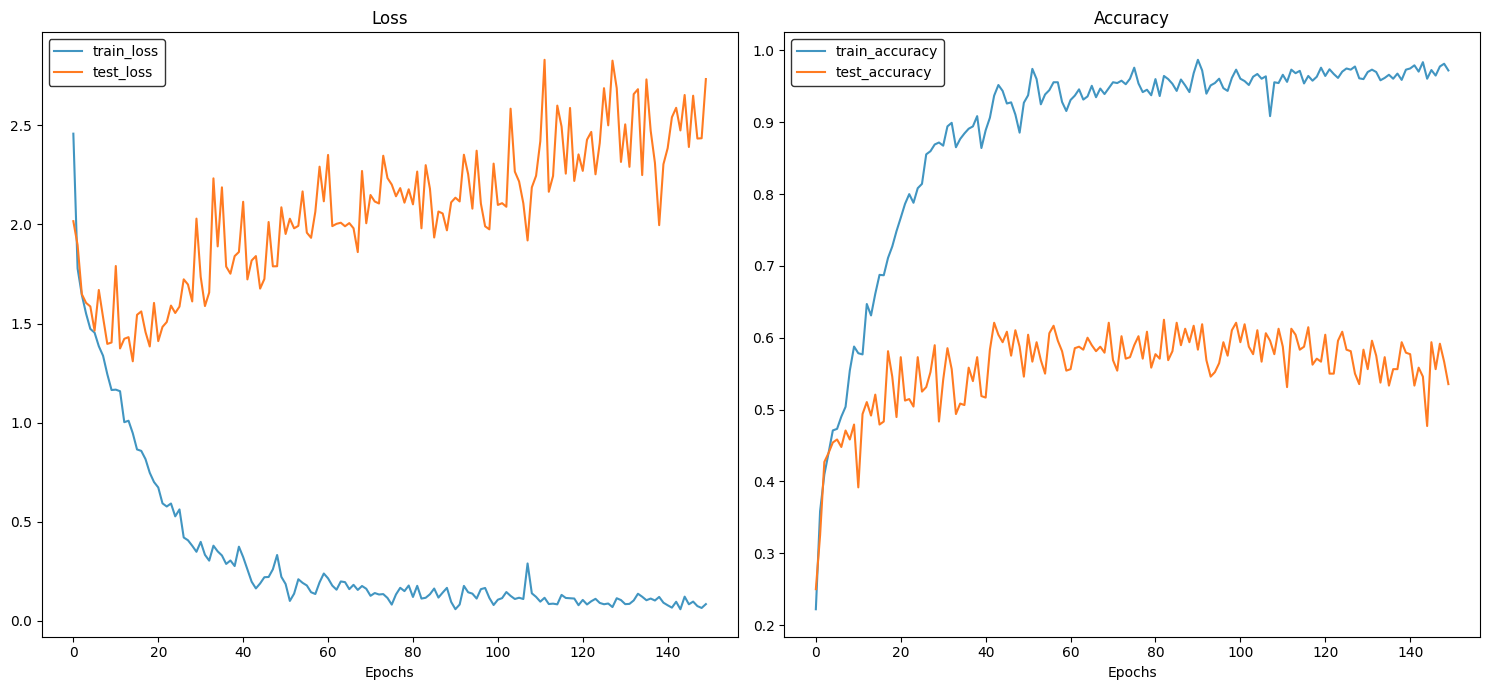

In [43]:
plot_loss_curves(model_0_results)

## 8. Using Data Augmentation

For our next models we are going to use data augmentation. This is a very common method to avoid overfitting. The method works as following:

During training, the model is exposed to the same data during each epoch. When implementing data augmentation, we alter the data on each epoch. In this way, the model is exposed to different data on each epoch, thus increasing the variety of data that it is exposed to. On each epoch a random alternation on the data is applied.

### 8.1 Implementing `TimeMasking()` and `FrequencyMasking()` on the data
The data augmentation we are going to use is `TimeMasking()` and `FrequencyMasking()`, both from the `torchaudio` library. Those methods will randomly mask up to a number of time frames and coefficients respectively. For more info - https://docs.pytorch.org/audio/main/tutorials/audio_feature_augmentation_tutorial.html#time-and-frequency-masking


> The `TimeMasking()` transform, "masks" the entire x axis for a specific amount. A good option would be to mask 15% of the sample. The *time_mask_param* is responsible for the amount of time frames that will be masked. We are calculating this value and setting it in the `TimeMasking()` transform.
>> __In case we divided the original GTZAN samples into 10 segments__: Our x axis is the time frames and we know that each sample has 130 time frames. We are going to mask 20 frames which is approximately 15% of the sample. This is done by setting the *time_mask_param* to 20. That means that maximum 20 consecutive frames will be masked.

> The `FrequencyMasking()` transform, "masks" the entire y axis for a specific amount. A good option would be to mask 12% of the sample. The *freq_mask_param* is responsible for the amount of mel bands that will be masked. We are calculating this value and setting it in the `FrequencyMasking()` transform.
>> __In case we divided the original GTZAN samples into 10 segments__:Our y axis is the mel bands and we know that each sample has 64 mel bands. We are going to mask 8 frames which is approximately 12% of the sample. This is done by setting the *freq_mask_param* to 8. That means that maximum 8 consecutive frames will be masked.

The masked spectograms are presented, to have a visualization of the augmented data. Similar methods of masking on log mel spectograms directly are mentioned in the SpecAugment paper. More info here - https://arxiv.org/pdf/1904.08779

_**Notice**: The time_mask_param and freq_mask_param will set the **maximum** amount of frames/mel banks that will be masked. This number will be random on each epoch._

In [44]:
# Calculating the proper time_mask_param and freq_mask_param values

# Shape is 72x72 so we cover 10 indices
time_mask_param = round(10)
freq_mask_param = round(10)

time_mask_param, freq_mask_param

(10, 10)

In [45]:
# Creating time masking transform and checking the shape of sample data
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

INDEX = np.random.randint(len(X))
time_masking = torchaudio.transforms.TimeMasking(time_mask_param=time_mask_param)
time_masked_data = time_masking(X[INDEX].squeeze()).to('cpu')
time_masked_data.shape

torch.Size([72, 72])

In [46]:
# Creating frequency masking transform and checking the shape of sample data
# np.random.seed(RANDOM_SEED)
# torch.manual_seed(RANDOM_SEED)

INDEX = np.random.randint(len(X))
freq_masking = torchaudio.transforms.FrequencyMasking(freq_mask_param=freq_mask_param)
freq_masked_data = freq_masking(X[INDEX].squeeze()).to('cpu')
freq_masked_data.shape

torch.Size([72, 72])

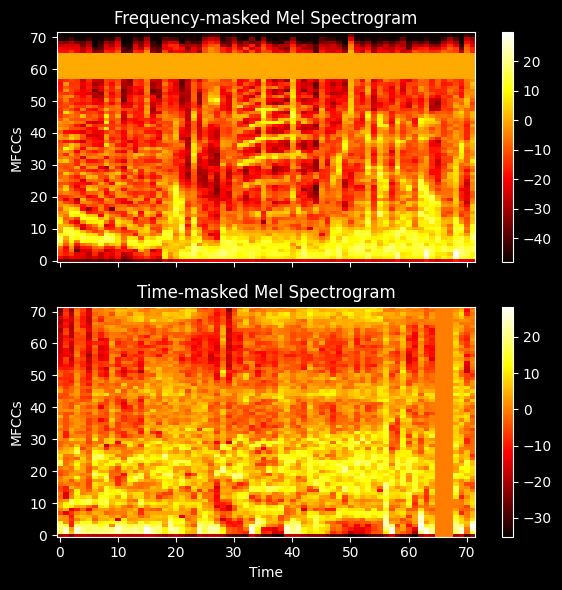

In [47]:
# Visualize data
time_masked_melspec_example = time_masked_data.numpy()
freq_masked_melspec_example = freq_masked_data.numpy()

fig, axes = plt.subplots(2, 1, figsize=(6, 6), sharex=True, sharey=True)
im0 = axes[0].imshow(time_masked_melspec_example.T, cmap='hot', aspect='auto', origin='lower')
axes[0].set_title("Frequency-masked Mel Spectrogram")
axes[0].set_ylabel("MFCCs")
fig.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(freq_masked_melspec_example.T, cmap='hot', aspect='auto', origin='lower')
axes[1].set_title("Time-masked Mel Spectrogram")
axes[1].set_xlabel("Time")
axes[1].set_ylabel("MFCCs")
fig.colorbar(im1, ax=axes[1])

fig.tight_layout()
plt.show()

### 8.2 Creating training functions for data augmentation

In [48]:
# Creating the transform instance
from torchaudio import transforms as T

torch.manual_seed(RANDOM_SEED)

train_transforms = nn.Sequential(
    T.TimeMasking(time_mask_param=time_mask_param),
    T.FrequencyMasking(freq_mask_param=freq_mask_param)
)

# Create a train loop function
def train_step_with_augmentation(model: torch.nn.Module,
               dataloader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer,
               use_augmentation=True):
    # Put model in train mode
    model.train()

    # Setup train loss and train accuracy values
    train_loss, train_acc = 0, 0

    # Loop through data loader data batches
    for batch, (X, y) in enumerate(dataloader):
        # Send data to target device
        X, y = X.to(device), y.to(device)

        # Implement augmentation
        if use_augmentation:
            X = train_transforms(X)

        # 1. Forward pass
        y_pred = model(X)

        # 2. Calculate  and accumulate loss
        loss = loss_fn(y_pred, y)
        train_loss += loss.item()

        # 3. Optimizer zero grad
        optimizer.zero_grad()

        # 4. Loss backward
        loss.backward()

        # 5. Optimizer step
        optimizer.step()

        # Calculate and accumulate accuracy metrics across all batches
        y_pred_class = torch.argmax(torch.softmax(y_pred, dim=1), dim=1)
        train_acc += (y_pred_class == y).sum().item()/len(y_pred)

    # Adjust metrics to get average loss and accuracy per batch
    train_loss = train_loss / len(dataloader)
    train_acc = train_acc / len(dataloader)
    return train_loss, train_acc

In [49]:
# Creating the function for training with data that have been augmented
def train_with_augmentation(model: torch.nn.Module,
          train_dataloader: torch.utils.data.DataLoader,
          test_dataloader: torch.utils.data.DataLoader,
          optimizer: torch.optim.Optimizer,
          loss_fn: torch.nn.Module = nn.CrossEntropyLoss(),
          epochs: int = 5):

    # 2. Create empty results dictionary
    results = {"train_loss": [],
        "train_acc": [],
        "test_loss": [],
        "test_acc": []
    }

    # 3. Loop through training and testing steps for a number of epochs
    for epoch in tqdm(range(epochs)):
        train_loss, train_acc = train_step_with_augmentation(model=model,
                                                            dataloader=train_dataloader,
                                                            loss_fn=loss_fn,
                                                            optimizer=optimizer,
                                                             use_augmentation=True)
        test_loss, test_acc = test_step(model=model,
            dataloader=test_dataloader,
            loss_fn=loss_fn)

        # 4. Print out what's happening
        print(
            f"Epoch: {epoch+1} | "
            f"train_loss: {train_loss:.4f} | "
            f"train_acc: {train_acc:.4f} | "
            f"test_loss: {test_loss:.4f} | "
            f"test_acc: {test_acc:.4f}"
        )

        # 5. Update results dictionary
        # Ensure all data is moved to CPU and converted to float for storage
        results["train_loss"].append(train_loss.item() if isinstance(train_loss, torch.Tensor) else train_loss)
        results["train_acc"].append(train_acc.item() if isinstance(train_acc, torch.Tensor) else train_acc)
        results["test_loss"].append(test_loss.item() if isinstance(test_loss, torch.Tensor) else test_loss)
        results["test_acc"].append(test_acc.item() if isinstance(test_acc, torch.Tensor) else test_acc)

    # 6. Return the filled results at the end of the epochs
    return results

### 8.3 Training the Transformer model using data augmentation

In [54]:
# Create model and put it to device
torch.manual_seed(RANDOM_SEED)
model_1 = ViT().to(device)
model_1

ViT(
  (patch_embedding): PatchEmbedding(
    (patcher): Conv2d(1, 768, kernel_size=(12, 12), stride=(12, 12))
    (flatten): Flatten(start_dim=2, end_dim=3)
  )
  (embedding_dropout): Dropout(p=0.1, inplace=False)
  (transformer_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-11): 12 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
        )
        (linear1): Linear(in_features=768, out_features=3072, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=3072, out_features=768, bias=True)
        (norm1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (mlp_head): Sequential(
    (0): LayerNorm((768,), eps=1e-05, 

In [55]:
# Create loss and optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_1.parameters(),
                             lr=0.001,
                             weight_decay=0.0001)

In [56]:
# Training the model using the train_with_augmentation function
# Set number of epochs
NUM_EPOCHS = 250

# Start the timer
from timeit import default_timer as timer
start_time = timer()

# Train model_1
model_1_results = train_with_augmentation(model=model_1,
                                          train_dataloader=train_dataloader,
                                          test_dataloader=validation_dataloader,
                                          optimizer=optimizer,
                                          loss_fn=loss_fn,
                                          epochs=NUM_EPOCHS)

# End the timer and print out how long it took
end_time = timer()
print(f"Total training time: {end_time-start_time:.3f} seconds")

  0%|          | 0/250 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 2.3782 | train_acc: 0.2122 | test_loss: 1.9128 | test_acc: 0.3042
Epoch: 2 | train_loss: 1.8632 | train_acc: 0.3405 | test_loss: 2.0714 | test_acc: 0.3354
Epoch: 3 | train_loss: 1.8026 | train_acc: 0.3613 | test_loss: 1.6975 | test_acc: 0.3333
Epoch: 4 | train_loss: 1.7375 | train_acc: 0.3761 | test_loss: 1.8097 | test_acc: 0.3646
Epoch: 5 | train_loss: 1.8096 | train_acc: 0.3575 | test_loss: 1.8841 | test_acc: 0.3729
Epoch: 6 | train_loss: 1.7971 | train_acc: 0.3602 | test_loss: 1.9465 | test_acc: 0.3229
Epoch: 7 | train_loss: 1.8285 | train_acc: 0.3421 | test_loss: 1.7649 | test_acc: 0.3750
Epoch: 8 | train_loss: 1.7885 | train_acc: 0.3607 | test_loss: 1.7240 | test_acc: 0.3750
Epoch: 9 | train_loss: 1.7695 | train_acc: 0.3569 | test_loss: 1.7610 | test_acc: 0.3708
Epoch: 10 | train_loss: 1.7810 | train_acc: 0.3503 | test_loss: 1.7848 | test_acc: 0.3250
Epoch: 11 | train_loss: 1.7032 | train_acc: 0.3717 | test_loss: 1.6598 | test_acc: 0.3854
Epoch: 12 | train_l

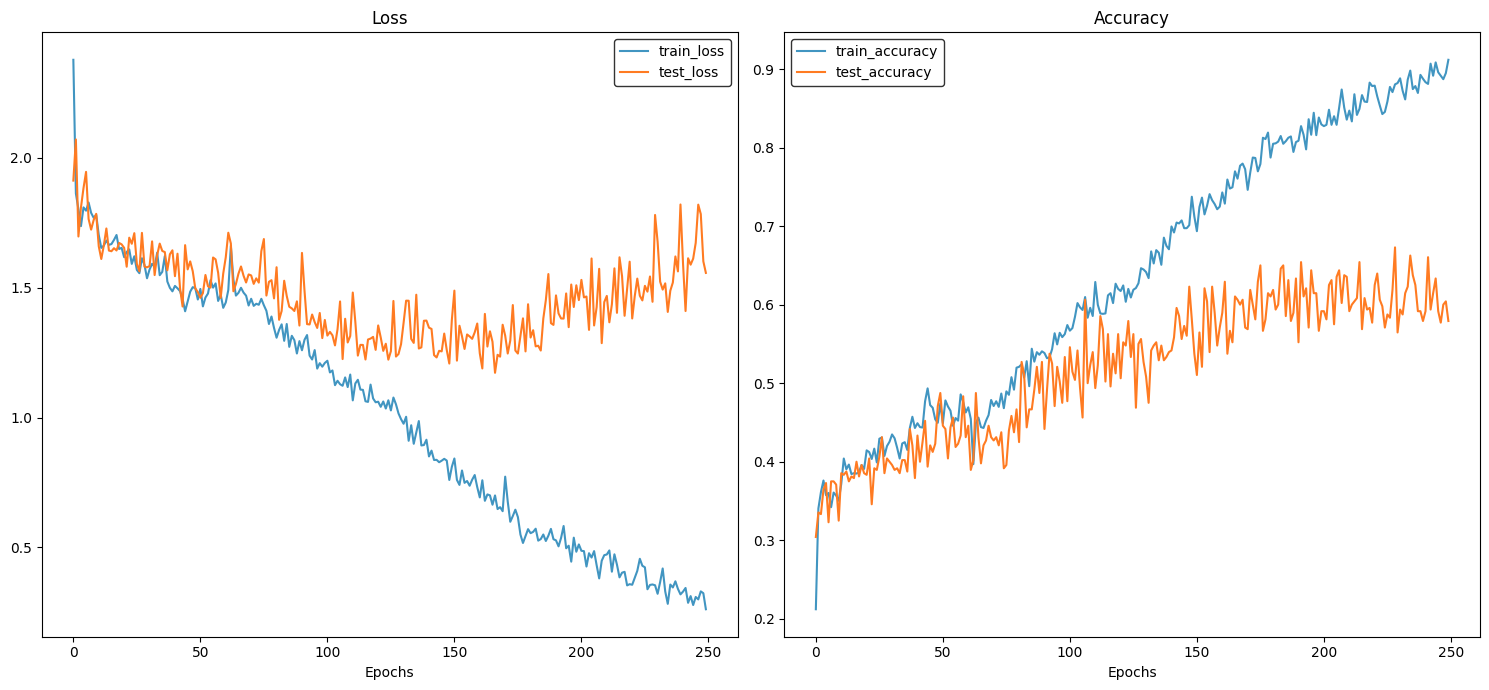

In [57]:
plot_loss_curves(model_1_results)

## 10. Using early stopping to create the best model

We will use early stopping on the models trained with data augmentation, in order to have the best version of them. One for each architecture.

In [58]:
# Instantiating a new Transformer model and putting it to device
torch.manual_seed(RANDOM_SEED)

model_2 = ViT().to(device)
model_2

ViT(
  (patch_embedding): PatchEmbedding(
    (patcher): Conv2d(1, 768, kernel_size=(12, 12), stride=(12, 12))
    (flatten): Flatten(start_dim=2, end_dim=3)
  )
  (embedding_dropout): Dropout(p=0.1, inplace=False)
  (transformer_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-11): 12 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
        )
        (linear1): Linear(in_features=768, out_features=3072, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=3072, out_features=768, bias=True)
        (norm1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (mlp_head): Sequential(
    (0): LayerNorm((768,), eps=1e-05, 

In [59]:
# Create loss and optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_2.parameters(),
                             lr=0.001,
                             weight_decay=0.0001)

In [60]:
# Training the model using the train_with_augmentation function
# Set number of epochs
NUM_EPOCHS = 170

# Start the timer
from timeit import default_timer as timer
start_time = timer()

# Train model_1
model_7_results = train_with_augmentation(model=model_2,
                                          train_dataloader=train_dataloader,
                                          test_dataloader=validation_dataloader,
                                          optimizer=optimizer,
                                          loss_fn=loss_fn,
                                          epochs=NUM_EPOCHS)

# End the timer and print out how long it took
end_time = timer()
print(f"Total training time: {end_time-start_time:.3f} seconds")

  0%|          | 0/170 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 2.3782 | train_acc: 0.2122 | test_loss: 1.9128 | test_acc: 0.3042
Epoch: 2 | train_loss: 1.8632 | train_acc: 0.3405 | test_loss: 2.0714 | test_acc: 0.3354
Epoch: 3 | train_loss: 1.8026 | train_acc: 0.3613 | test_loss: 1.6975 | test_acc: 0.3333
Epoch: 4 | train_loss: 1.7375 | train_acc: 0.3761 | test_loss: 1.8097 | test_acc: 0.3646
Epoch: 5 | train_loss: 1.8096 | train_acc: 0.3575 | test_loss: 1.8841 | test_acc: 0.3729
Epoch: 6 | train_loss: 1.7971 | train_acc: 0.3602 | test_loss: 1.9465 | test_acc: 0.3229
Epoch: 7 | train_loss: 1.8285 | train_acc: 0.3421 | test_loss: 1.7649 | test_acc: 0.3750
Epoch: 8 | train_loss: 1.7885 | train_acc: 0.3607 | test_loss: 1.7240 | test_acc: 0.3750
Epoch: 9 | train_loss: 1.7695 | train_acc: 0.3569 | test_loss: 1.7610 | test_acc: 0.3708
Epoch: 10 | train_loss: 1.7810 | train_acc: 0.3503 | test_loss: 1.7848 | test_acc: 0.3250
Epoch: 11 | train_loss: 1.7032 | train_acc: 0.3717 | test_loss: 1.6598 | test_acc: 0.3854
Epoch: 12 | train_l

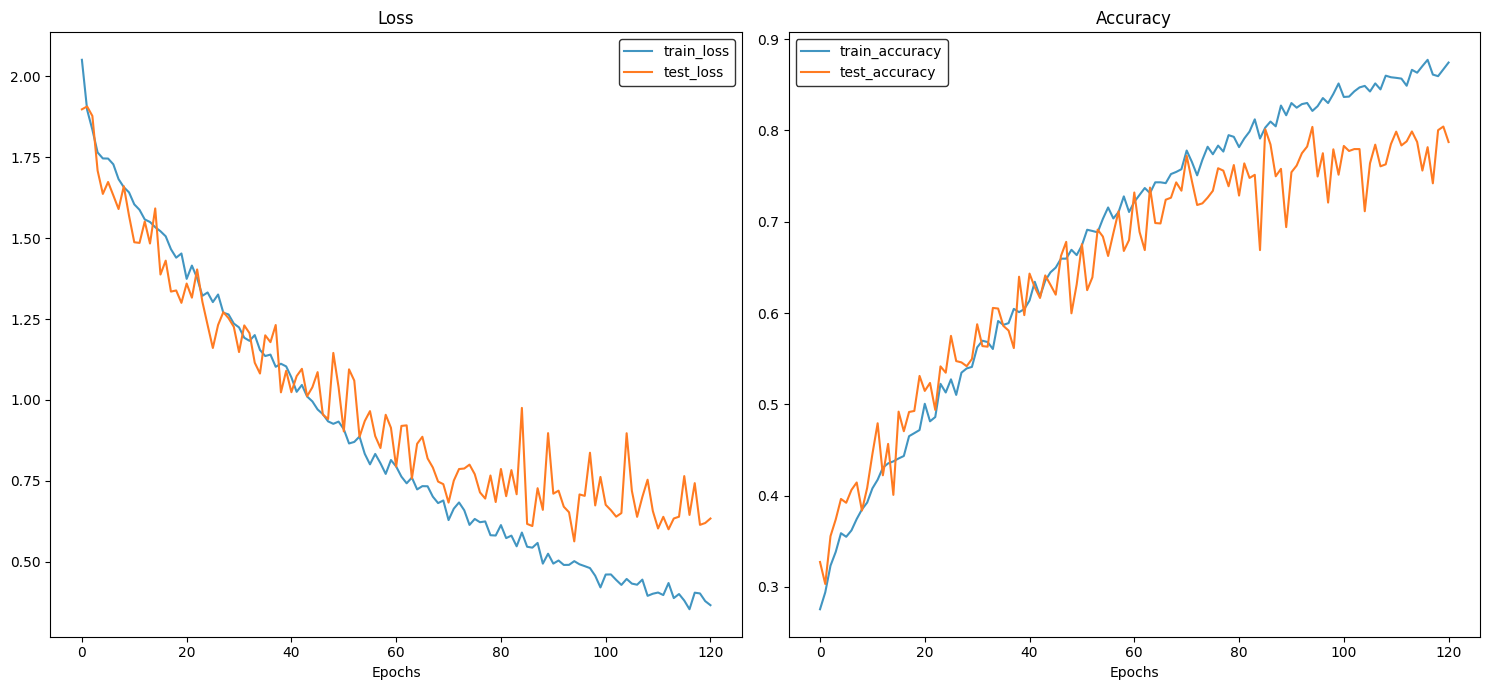

In [51]:
plot_loss_curves(model_7_results)

## 10. Evaluating our model on never seen data

Finally, we are going to use the `test_dataloader` to evaluate our models.

In [61]:
# Evaluate the RNN on the test set
evaluation = test_step(model=model_2,
                       dataloader=test_dataloader,
                       loss_fn=loss_fn,
                       )
print(f"test loss = {evaluation[0]:.4f} | test acc = {evaluation[1]:.4f}")

test loss = 1.5209 | test acc = 0.5677


## 12. Creating a `predict()` function, to make predictions on unseen data

We are going to use our models to make predictions. First we use the test dataloader to extract the first sample. Then we create the predict function that among other arguments, we can enter the index of the sample we want to predict. We see that we have 2499 indexes available.
The tensor that represents the sample has to be unsqueezed because the model expects a `batch_size` on dim=0. The model exports logits. Using `softmax()` we turn the logits into probabilities and with `argmax()` we take the index of the highest probability. This is actually the predicted index class. However, we can use `argmax()` right away without having the probabilites first. This is because logit values are respective to the probability values. This is actually the predicted index class. We also do that for time complexity reasons.

Changing the `model` and `index` arguments on the `predict()` function can let us make further testing.

In [62]:
# Creating the predict() function
def predict(model: torch.nn.Module,
            X_test: torch.Tensor,
            y_test: torch.Tensor,
            index: int = 0,
            device: str = "cpu",
            classes: list = classes):

    X_sample = X_test[index].unsqueeze(0).to(device)  # (1, C, H, W)
    y_sample = y_test[index].item() if isinstance(y_test[index], torch.Tensor) else y_test[index]

    model.eval()
    with torch.inference_mode():
        logits = model(X_sample)
        predicted_index = torch.argmax(logits, dim=1).item()

    print(f"Target: {classes[y_sample]}, Predicted label: {classes[predicted_index]}")

In [63]:
# Printing the shape to see how many indexes we have
X_test.shape

torch.Size([750, 1, 72, 72])

In [64]:
# Set random seed to define index.
np.random.seed(RANDOM_SEED) # remove this line to set a random index, for further testing
index = np.random.randint(len(X_test))
predict(model=model_2,
        X_test=X_test,
        y_test=y_test,
        index=200,
        device=device,
        classes=classes)

Target: hiphop, Predicted label: reggae


## 13. Making a confusion matrix for further evaluation

For a good vizualization of our model's performance, we can use a confusion matrix for our models. For that purpose we will use the `torchmetrics` and `mlxtend` library.
First we will make predictions on a test set and save the results on a tensor. Then we can use this tensor along with `y_test` which is a tensor containing the correct values for the labels of the test set.

In [65]:
# Importing libraries
import mlxtend
print(f"mlxtend version: {mlxtend.__version__}")
assert int(mlxtend.__version__.split(".")[1]) >= 19, "mlxtend verison should be 0.19.0 or higher. use pip install -q torchmetrics -U mlxtend"

mlxtend version: 0.24.0


In [66]:
# Make predictions on test_set and get tensor with predictions
from tqdm.auto import tqdm

# 1. Make predictions with trained model
y_preds = []
model_2.eval()
with torch.inference_mode():
  for X, y in tqdm(test_dataloader, desc="Making predictions"):
    # Send data and targets to target device
    X, y = X.to(device), y.to(device)
    # Do the forward pass
    y_logit = model_2(X)
    # Turn predictions from logits -> prediction probabilities -> predictions labels
    y_pred = torch.softmax(y_logit, dim=1).argmax(dim=1) # note: perform softmax on the "logits" dimension, not "batch" dimension (in this case we have a batch size of 32, so can perform on dim=1)
    # Put predictions on CPU for evaluation
    y_preds.append(y_pred.cpu())
# Concatenate list of predictions into a tensor
y_pred_tensor = torch.cat(y_preds)

Making predictions:   0%|          | 0/24 [00:00<?, ?it/s]

In [67]:
# Importing libraries
from torchmetrics import ConfusionMatrix
from mlxtend.plotting import plot_confusion_matrix

# Setup confusion matrix instance and compare predictions to targets
confmat = ConfusionMatrix(num_classes=len(classes), task='multiclass')
confmat_tensor = confmat(preds=y_pred_tensor,
                         target=y_test)

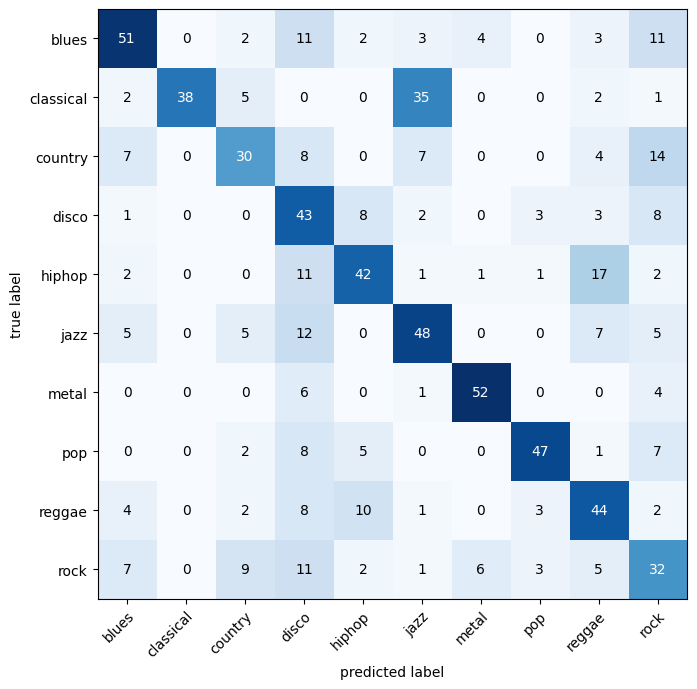

In [68]:
# Plot the confusion matrix
fig, ax = plot_confusion_matrix(
    conf_mat=confmat_tensor.numpy(),  # matplotlib likes working with NumPy
    class_names=classes,
    figsize=(10, 7)
)

# Figure & axes background
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

# Axis labels styling
ax.set_xlabel("predicted label", color='black')
ax.set_ylabel("true label", color='black')

ax.tick_params(axis='x', colors='black', rotation=45)
ax.tick_params(axis='y', colors='black')

# Spines
for spine in ax.spines.values():
    spine.set_color('black')

# Cell text (numbers inside matrix)
# We take each tex
# Retrieve all text annotations added by plot_confusion_matrix
for text in ax.texts:
    text.set_color('white' if float(text.get_text()) > confmat_tensor.max() / 2 else 'black')

# Colorbar styling
if len(fig.axes) > 1:  # second axis = colorbar
    cbar_ax = fig.axes[1]
    cbar_ax.tick_params(color='black')
    plt.setp(cbar_ax.get_yticklabels(), color='black')

# Layout
plt.tight_layout()

# # Save
# plt.savefig(
#     "MLP_confusion_matrix.png",
#     dpi=144,
#     bbox_inches='tight',
#     facecolor=fig.get_facecolor()
# )

plt.show()